# ショアのアルゴリズムによる素因数分解

少なくとも100桁はあるような大きな数 $N$ が与えられたとき、$N$ の因数をどうやって見つければよいでしょうか。有名な古典アルゴリズムがいくつか存在し、[Wikipedia](https://en.wikipedia.org/wiki/Integer_factorization)にはそれらの網羅的なリストがあります。巨大な整数に対して知られている最良のアルゴリズムは一般数体篩法であり、実行時間は $\exp(O(\ln N)^{1/3}(\ln\ln N)^{2/3})$ です。

素因数分解は間違いなく難しい問題ですが、$\text{poly}(n)$ 時間(ここで $n = \lceil\log_2 N\rceil$)で解けるかどうかは分かっていません。素因数分解は $P$ に属さないと広く考えられており、これが現在使われているRSAなどの暗号プロトコルの基盤になっています。

ショアのアルゴリズムは、素因数分解問題に対する高速な量子アルゴリズムを提供します(入力ビット数の多項式時間)。このチュートリアルでは、それがどのように合成数の因数を見つけるのかを見ていきます。

## パート I: 素因数分解の位数発見問題への帰着

まず、$\{2,\ldots, N-1\}$ から一様ランダムに $x$ を選びます。[ユークリッドの互除法](http://www-math.ucdenver.edu/~wcherowi/courses/m5410/exeucalg.html)を使えば $\text{gcd}(x,N)$ を効率よく求めることができます。もし $\text{gcd}(x,N)\neq 1$ であれば、運良く $N$ の因数を見つけたことになります!そうでなければ、まだ作業が残っています…

$x^r\equiv 1 \mod N$ となる最小の整数(*位数*と呼ばれます)を $r\ge 1$ とします。$r$ が偶数であれば、
$$ (x^{r/2}-1)(x^{r/2}+1)\equiv 0 \mod N,$$
が成り立つため、$\text{gcd}(x^{r/2}-1, N)$ または $\text{gcd}(x^{r/2}+1, N)$ が $N$ の因数 $d$ を与えます。そうすれば、同じ位数発見アルゴリズムを $N/d$ に対して再帰的に実行できます。

したがって、$x$ の $N$ を法とした位数 $r = A(x,N)$ を効率よく計算する方法があれば、以下のように素因数分解問題を解くことができます。

> factorize($N$):
> + $\{2,\ldots,N-1\}$ から一様ランダムに $x$ を選ぶ。
> + もし $d = \text{gcd}(x,N)\neq 1$ ならば、$d$ を因数として返し、_factorize($N/d$)_ を実行する。
> + そうでなければ:
>     - $r = A(x,N)$ とする。
>     - $r$ が偶数ならば、$\text{gcd}(x^{r/2}-1, N)$ または $\text{gcd}(x^{r/2}+1, N)$ が因数 $d$ を与える。$d$ を返し、_factorize($N/d$)_ を実行する。
>     - そうでなければ、別の $x$ を一様ランダムに選び直して繰り返す。

## パート II: 位数を見つける
$r = A(x,n)$ の値を計算するために、まず以下を満たすユニタリ演算子 $U_x$ が必要です。
$$U_x\lvert j\rangle_t \lvert k\rangle_n = \lvert j\rangle_t \lvert k\oplus (x^j\mbox{ mod } N)\rangle_n.$$

次に、$t$個の量子ビットからなるレジスタ1と、$n$個の量子ビットからなるレジスタ2を持つ以下の回路を考えます。

<img src="img/104_shor_ckt.png" alt="shor-circuit" width="600"/>

ここで一般に $n=\lceil \log_2N\rceil$、$t=\lceil 2\log_2 N\rceil$ です。$r=A(x,n)$ が2のべき乗である場合、$t$ の選び方は $t=n=\lceil \log_2N\rceil$ と単純化できます。まずこの特殊な場合を考えます。

### ケース1: 位数が2のべき乗の場合
初期化後、以下の状態が得られます。

$$\varphi_1 = \frac 1{\sqrt{2^t}}\sum_{j=0}^{2^t-1}\lvert j\rangle \lvert 0\rangle,$$

したがって、

$$\varphi_2 = U_x\varphi_1 = \frac 1{\sqrt{2^t}}\sum_{j=0}^{2^t-1}\lvert j\rangle \lvert x^j\mbox{ mod }N\rangle.$$

$\varphi_2$ は、$2^t$ より小さい各整数 $j$ について計算した $x^j\mbox{ mod }N$ すべてを符号化したものと考えることができ、$x^j\mbox{ mod }N=1$ となる最小の $j$ を見つけることに関心があります。

計算を簡単にするため、まず2番目のレジスタを測定します。任意の $j$ は

$$ j = ar+b, \mbox{ ただし }0\le a < 2^t/r \mbox{ かつ } 0\le b <r,$$

と書けることに注意すると、$\varphi_2$ を以下の二重和として書くことができます。

$$\varphi_2 = \frac 1{\sqrt{2^t}}\sum_{b=0}^{r-1}\sum_{a=0}^{2^t/r -1}\lvert ar+b\rangle\lvert x^{ar+b}\mbox{ mod }N\rangle.$$

$x^{ar+b}\mbox{ mod }N = x^b\mbox{ mod }N$ であることに注意してください。また、この場合 $r$ は2のべき乗であるため $2^t/r$ は整数であることを思い出してください。したがって、最終的に以下のように書けます。

$$\varphi_2 = \frac 1{\sqrt{2^t}}\sum_{b=0}^{r-1}\sum_{a=0}^{2^t/r -1}\lvert ar+b\rangle\lvert x^{b}\mbox{ mod }N\rangle.$$

ここで2番目のレジスタを測定します。$x^0, \ldots, x^{r-1}$ の各値は等しい確率で測定されます。測定結果を $x^{b_0}$ とすると、$\varphi_2$ は以下の状態になります。

$$\varphi_3 = \frac{\sqrt r}{\sqrt{2^t}}\sum_{a=0}^{2^t/r - 1} \lvert ar+b_0\rangle \lvert x^{b_0}\mbox{ mod }N \rangle.$$

ここで不確定なのは最初のレジスタだけであり、測定すれば各状態 $\lvert ar+b_0\rangle, 0\le a<2^t/r$ が $r/2^t$ の確率で測定されます。最後に、最初のレジスタに逆量子フーリエ変換を適用します。$\mbox{QFT}$ と $\mbox{QFT}^\dagger$ の作用はすでに説明済みなので、これを使って回路の最終的な量子状態を以下のように計算できます。

$$
\begin{aligned}\varphi_4 &= \frac{\sqrt{r}}{\sqrt{2^t}} \sum_{a=0}^{2^t/r-1}\left[\frac1{\sqrt{2^t}}\sum_{j=0}^{2^t-1}\exp\left(\frac{-2\pi i j(ar+b_0)}{2^r}\right)\lvert j\rangle \right]\lvert x^{b_0}\mbox{ mod }N \rangle\\
& = \frac1{\sqrt r}\left[\sum_{j=0}^{2^t-1}\left(\frac r{2^t}\sum_{a=0}^{2^t/r-1}\exp\left(\frac{-2\pi ija}{2^t/r}\right) \right)\exp\left(\frac{-2\pi ijb_0}{2^t}\right)\lvert j\rangle\right]\lvert x^{b_0}\mbox{ mod }N \rangle\end{aligned}.
$$

フーリエ級数の性質 $\frac 1N\sum_{j=0}^{N-1} \exp(2\pi ijk/N) = 1$ ($k$ が $N$ の倍数のとき、それ以外は $0$)を使うと、内側の括弧の中の式はほとんどの場合 $0$ になることが分かります。$j$ が $2^t/r$ の倍数のときだけ非ゼロの値になります。したがって、

$$\varphi_4 = \frac 1{\sqrt r}\sum_{k=0}^{r-1}\exp\left(\frac{-2\pi ikb_0}r\right) \lvert k2^t/r\rangle \lvert x^{b_0}\mbox{ mod }N\rangle.$$

したがって、$\varphi_4$ を測定した結果は $0\le k \le r-1$ について $k2^t/r$ になります。

では $\varphi_4$ を測定してみましょう。結果 $B = k_02^t/r$ について、以下の手順を行います。

+ 結果 $B$ が $0$ であれば、$r$ についての情報は得られないため、回路を再度実行します。
+ ある $0 < k_0\le r-1$ について $B = k_02^t/r$ が得られた場合、$k_0/r = B/2^t$ を計算します。すると $B/2^t$ の分母が $r$ を割り切ることが分かります。
  - この分母を $r_1$ とします。もし $x^{r_1}\mbox{ mod }N = 1$ であれば、$r_1$ が位数であり、終了できます。
  - そうでなければ、$r_2 = r/r_1$ とします。$r_2$ は $x^{r_1}$ の位数であることに注意し、$x^{r_1}$ の位数を求めるためにアルゴリズムを再度実行します。位数 $r$ の全体が分かるまでこれを再帰的に適用します。

以上がショアのアルゴリズムの完全な説明です。技術的ではありますが、基本ステップが明確な効率的アルゴリズムです。ケース2の議論は後のセクションに回します。

### ケース1に対するショアのアルゴリズムの実装
それでは、$N=15$ を素因数分解するショアのアルゴリズムを実装してみましょう。$15$ を選ぶのは、$15$ より小さく $15$ と互いに素な数 $\{1,2,4,7,8,11,13,14\}$ の位数がすべて $2$ か $4$ であり、理想的な回路になるためです。

最初のレジスタに $t=4$ 量子ビット、2番目のレジスタに $n=4$ 量子ビットが必要であることを思い出してください。
ここでは、$15$ を法とした $7$ の位数を求めることに注目します。

### $U_x$ の実装
ショアのアルゴリズムを実装する上での主な課題の1つは、実際のゲートを使って回路 $U_x$ を構成することです。$N=15$ の場合の $x^b\mbox{ mod }N$ の実装は[Markov-Saeedi](https://arxiv.org/pdf/1202.6614.pdf)から借用します。

In [1]:
# Install blueqat!
# !pip install git+https://github.com/blueqat/blueqatSDK

# Import libraries
from blueqat import Circuit
import numpy as np
from collections import Counter as _Counter

# Compatibility note: the new blueqat SDK reports measurement bitstrings with
# qubit 0 as the right-most character (standard binary ordering), while this
# notebook (like the old blueqat 0.3.x) reads qubit 0 as the left-most
# character. Patch Circuit.run once so sampled bitstrings keep matching the
# qubit ordering used throughout this notebook's explanation.
if not getattr(Circuit, '_qubit0_leftmost_patched', False):
    _original_run = Circuit.run
    def _run_qubit0_leftmost(self, *args, **kwargs):
        result = _original_run(self, *args, **kwargs)
        if isinstance(result, _Counter):
            return _Counter({key[::-1]: count for key, count in result.items()})
        return result
    Circuit.run = _run_qubit0_leftmost
    Circuit._qubit0_leftmost_patched = True

# Recall QFT dagger from our previous tutorial
def apply_qft_dagger(circuit: Circuit(), qubits):
    num_qubits = len(qubits)
    # Reverse the order of qubits at the end
    for i in range(int(num_qubits/2)):
        circuit.swap(qubits[i],qubits[num_qubits-i-1])
    for i in range(num_qubits):
        for j in range(i):
            circuit.cphase(-np.pi/(2 ** (j-i)))[qubits[j],qubits[i]]
        circuit.h[qubits[i]]

In [2]:
# Implementation of U_x as a black box. More details can be found in the previously mentioned paper.
def apply_U_7_mod15(circuit: Circuit(), qubits):
    assert len(qubits) == 8, 'Must have 8 qubits as input.'
    circuit.x[qubits[7]]
    circuit.ccx[qubits[0],qubits[6],qubits[7]]
    circuit.ccx[qubits[0],qubits[7],qubits[6]]
    circuit.ccx[qubits[0],qubits[6],qubits[7]]
    circuit.ccx[qubits[0],qubits[5],qubits[6]]
    circuit.ccx[qubits[0],qubits[6],qubits[5]]
    circuit.ccx[qubits[0],qubits[5],qubits[6]]
    circuit.ccx[qubits[0],qubits[4],qubits[5]]
    circuit.ccx[qubits[0],qubits[5],qubits[4]]
    circuit.ccx[qubits[0],qubits[4],qubits[5]]
    circuit.cx[qubits[0],qubits[4]]
    circuit.cx[qubits[0],qubits[5]]
    circuit.cx[qubits[0],qubits[6]]
    circuit.cx[qubits[0],qubits[7]]
    circuit.ccx[qubits[1],qubits[6],qubits[7]]
    circuit.ccx[qubits[1],qubits[7],qubits[6]]
    circuit.ccx[qubits[1],qubits[6],qubits[7]]
    circuit.ccx[qubits[1],qubits[5],qubits[6]]
    circuit.ccx[qubits[1],qubits[6],qubits[5]]
    circuit.ccx[qubits[1],qubits[5],qubits[6]]
    circuit.ccx[qubits[1],qubits[4],qubits[5]]
    circuit.ccx[qubits[1],qubits[5],qubits[4]]
    circuit.ccx[qubits[1],qubits[4],qubits[5]]
    circuit.cx[qubits[1],qubits[4]]
    circuit.cx[qubits[1],qubits[5]]
    circuit.cx[qubits[1],qubits[6]]
    circuit.cx[qubits[1],qubits[7]]
    circuit.ccx[qubits[1],qubits[6],qubits[7]]
    circuit.ccx[qubits[1],qubits[7],qubits[6]]
    circuit.ccx[qubits[1],qubits[6],qubits[7]]
    circuit.ccx[qubits[1],qubits[5],qubits[6]]
    circuit.ccx[qubits[1],qubits[6],qubits[5]]
    circuit.ccx[qubits[1],qubits[5],qubits[6]]
    circuit.ccx[qubits[1],qubits[4],qubits[5]]
    circuit.ccx[qubits[1],qubits[5],qubits[4]]
    circuit.ccx[qubits[1],qubits[4],qubits[5]]
    circuit.cx[qubits[1],qubits[4]]
    circuit.cx[qubits[1],qubits[5]]
    circuit.cx[qubits[1],qubits[6]]
    circuit.cx[qubits[1],qubits[7]]
    circuit.ccx[qubits[2],qubits[6],qubits[7]]
    circuit.ccx[qubits[2],qubits[7],qubits[6]]
    circuit.ccx[qubits[2],qubits[6],qubits[7]]
    circuit.ccx[qubits[2],qubits[5],qubits[6]]
    circuit.ccx[qubits[2],qubits[6],qubits[5]]
    circuit.ccx[qubits[2],qubits[5],qubits[6]]
    circuit.ccx[qubits[2],qubits[4],qubits[5]]
    circuit.ccx[qubits[2],qubits[5],qubits[4]]
    circuit.ccx[qubits[2],qubits[4],qubits[5]]
    circuit.cx[qubits[2],qubits[4]]
    circuit.cx[qubits[2],qubits[5]]
    circuit.cx[qubits[2],qubits[6]]
    circuit.cx[qubits[2],qubits[7]]
    circuit.ccx[qubits[2],qubits[6],qubits[7]]
    circuit.ccx[qubits[2],qubits[7],qubits[6]]
    circuit.ccx[qubits[2],qubits[6],qubits[7]]
    circuit.ccx[qubits[2],qubits[5],qubits[6]]
    circuit.ccx[qubits[2],qubits[6],qubits[5]]
    circuit.ccx[qubits[2],qubits[5],qubits[6]]
    circuit.ccx[qubits[2],qubits[4],qubits[5]]
    circuit.ccx[qubits[2],qubits[5],qubits[4]]
    circuit.ccx[qubits[2],qubits[4],qubits[5]]
    circuit.cx[qubits[2],qubits[4]]
    circuit.cx[qubits[2],qubits[5]]
    circuit.cx[qubits[2],qubits[6]]
    circuit.cx[qubits[2],qubits[7]]
    circuit.ccx[qubits[2],qubits[6],qubits[7]]
    circuit.ccx[qubits[2],qubits[7],qubits[6]]
    circuit.ccx[qubits[2],qubits[6],qubits[7]]
    circuit.ccx[qubits[2],qubits[5],qubits[6]]
    circuit.ccx[qubits[2],qubits[6],qubits[5]]
    circuit.ccx[qubits[2],qubits[5],qubits[6]]
    circuit.ccx[qubits[2],qubits[4],qubits[5]]
    circuit.ccx[qubits[2],qubits[5],qubits[4]]
    circuit.ccx[qubits[2],qubits[4],qubits[5]]
    circuit.cx[qubits[2],qubits[4]]
    circuit.cx[qubits[2],qubits[5]]
    circuit.cx[qubits[2],qubits[6]]
    circuit.cx[qubits[2],qubits[7]]
    circuit.ccx[qubits[2],qubits[6],qubits[7]]
    circuit.ccx[qubits[2],qubits[7],qubits[6]]
    circuit.ccx[qubits[2],qubits[6],qubits[7]]
    circuit.ccx[qubits[2],qubits[5],qubits[6]]
    circuit.ccx[qubits[2],qubits[6],qubits[5]]
    circuit.ccx[qubits[2],qubits[5],qubits[6]]
    circuit.ccx[qubits[2],qubits[4],qubits[5]]
    circuit.ccx[qubits[2],qubits[5],qubits[4]]
    circuit.ccx[qubits[2],qubits[4],qubits[5]]
    circuit.cx[qubits[2],qubits[4]]
    circuit.cx[qubits[2],qubits[5]]
    circuit.cx[qubits[2],qubits[6]]
    circuit.cx[qubits[2],qubits[7]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[7],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[4]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.cx[qubits[3],qubits[4]]
    circuit.cx[qubits[3],qubits[5]]
    circuit.cx[qubits[3],qubits[6]]
    circuit.cx[qubits[3],qubits[7]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[7],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[4]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.cx[qubits[3],qubits[4]]
    circuit.cx[qubits[3],qubits[5]]
    circuit.cx[qubits[3],qubits[6]]
    circuit.cx[qubits[3],qubits[7]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[7],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[4]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.cx[qubits[3],qubits[4]]
    circuit.cx[qubits[3],qubits[5]]
    circuit.cx[qubits[3],qubits[6]]
    circuit.cx[qubits[3],qubits[7]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[7],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[4]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.cx[qubits[3],qubits[4]]
    circuit.cx[qubits[3],qubits[5]]
    circuit.cx[qubits[3],qubits[6]]
    circuit.cx[qubits[3],qubits[7]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[7],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[4]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.cx[qubits[3],qubits[4]]
    circuit.cx[qubits[3],qubits[5]]
    circuit.cx[qubits[3],qubits[6]]
    circuit.cx[qubits[3],qubits[7]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[7],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[4]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.cx[qubits[3],qubits[4]]
    circuit.cx[qubits[3],qubits[5]]
    circuit.cx[qubits[3],qubits[6]]
    circuit.cx[qubits[3],qubits[7]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[7],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[4]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.cx[qubits[3],qubits[4]]
    circuit.cx[qubits[3],qubits[5]]
    circuit.cx[qubits[3],qubits[6]]
    circuit.cx[qubits[3],qubits[7]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[7],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[7]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[6],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[6]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.ccx[qubits[3],qubits[5],qubits[4]]
    circuit.ccx[qubits[3],qubits[4],qubits[5]]
    circuit.cx[qubits[3],qubits[4]]
    circuit.cx[qubits[3],qubits[5]]
    circuit.cx[qubits[3],qubits[6]]
    circuit.cx[qubits[3],qubits[7]]

In [3]:
# Now we build the Shor Circuit!
circuit = Circuit(8)
register1 = list(range(4))
register2 = list(range(4,8))
qubits = register1+register2
for i in register1:
    circuit.h[i]
apply_U_7_mod15(circuit, qubits)
apply_qft_dagger(circuit, register1)

# Run and measure the outcome from first register.
# In the theory we measure the second register first to reduce complexity of calculations.
# But that is unnecessary for the final outcome.
circuit.m[0:4].run(shots=10000)

Counter({'10000000': 2531,
         '00000000': 2517,
         '01000000': 2507,
         '11000000': 2445})

増幅された状態は $\lvert 0000\rangle, \lvert 0100\rangle, \lvert 1000\rangle, \lvert 1100\rangle$ です。これらは10進数で $0,4,8,12$ を表します。したがって、
$k_0/r = B/16$ は $0, \frac 14, \frac 12, \frac 34$ の値を取り得るため、位数の候補として $1,2,4$ が得られます。$7^1, 7^2$ が $1 \mbox{ mod }15$ でないことは明らかなので、$15$ を法とした $7$ の位数は $4$ であることが分かります!

### ケース2: 位数が2のべき乗でない場合
その場合、$N^2\le 2^t < 2N^2$(つまり $t=\lceil2 \log_2 N\rceil$)となるように $t$ を選んだことを思い出してください。ここでは $N=21$ の場合についてショアのアルゴリズムの例を示し、一般化を説明します。$N$ と互いに素な $x=2$ を選びます。

すると、
$$\begin{aligned}\varphi_1 &= \frac 1{\sqrt{512}}\sum_{j=0}^{512}\lvert j\rangle \lvert 0\rangle, \\
\varphi_2 & = \frac 1{\sqrt{512}}\sum_{j=0}^{512}\lvert j\rangle \lvert 2^j\mbox{ mod }N\rangle \\
    & = \frac 1{\sqrt{512}}\left[\psi_0\lvert 1\rangle + \psi_1\lvert 2\rangle + \psi_2\lvert 4\rangle + \psi_3\lvert 8\rangle + \psi_{4}\lvert 16\rangle + \psi_{5}\lvert 11\rangle\right],\end{aligned}$$

ここで $\psi_0 = \lvert 0\rangle + \lvert 6\rangle + \cdots + \lvert 510\rangle$ は $0\mbox{ mod }6$ となるすべての状態の重ね合わせであり、$\psi_1$ は $1\mbox{ mod }6$ のもの、というように続きます。
ここで、2番目のレジスタで $4$ が測定されたとすると、

$$\varphi_3 = \frac1{\sqrt{86}} \sum_{a=0}^{85} \lvert 6a+2\rangle,$$

したがって、
$$\varphi_4 = \frac 1{\sqrt{512}}\sum_{j=0}^{511}\left[\left(\frac{1}{\sqrt{86}}\sum_{a=0}^{85}\exp(\frac{-2\pi i \cdot 6 j a}{512})\right)\exp(\frac{-2\pi i\cdot 2j}{512})\lvert j\rangle\right]\lvert 2\rangle.$$

すると、状態 $j$ が測定される確率は
$$P(j) = \frac{1}{512\cdot 86}\left\lvert\sum_{a=0}^{85}\exp(\frac{-2\pi i \cdot 6 j a}{512})\right\rvert^2.$$

$P(j)$ を $j$ に対してプロットしてみましょう。

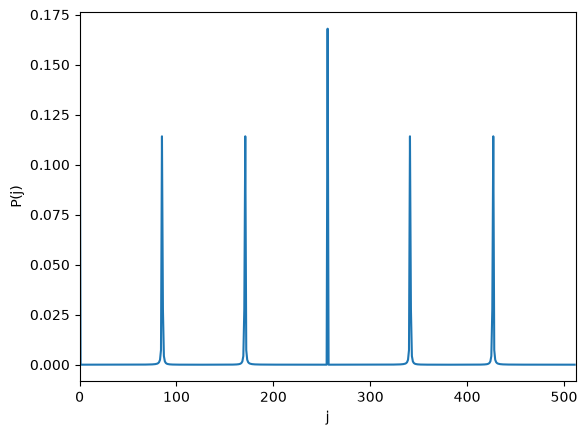

In [4]:
import matplotlib.pyplot as plt
N = 512
P = []
for j in range (N):
    s = 0
    for a in range(86):
        theta = -2*np.pi*6*j*a/float(512)
        s += complex(np.cos(theta), np.sin(theta))
    P.append((s.real **2  + s.imag ** 2)/float(86*512))
# print(P)
# the histogram of the data
plt.plot(range(N),P)
plt.xlim(0,N)
plt.xlabel('j')
plt.ylabel('P(j)')
plt.show()

以下の5点でピークが得られることが分かります。

In [5]:
peaks = [i for i in range(N) if P[i] > 0.05]
print(peaks)

[0, 85, 171, 256, 341, 427]


$0$ が測定された場合は運が悪く、アルゴリズムを再実行する必要があります。代わりに $B=85$ が測定されたとしましょう。すると $\frac B{512}=\frac{85}{512}$ となり、ここから $r$ を求める必要があります。$\frac{85}{512}$ は $\frac{k_0}{r}$ の有理数近似であるため、連分数の方法を使って $r$ を求めることができます!

以下のように行います。

In [6]:
import pandas as pd
import fractions

rows = []
for i in peaks:
    f = fractions.Fraction(i/512).limit_denominator(15)
    rows.append([i, f.denominator])
print(pd.DataFrame(rows, columns=["Peak", "Guess for r"]))

   Peak  Guess for r
0     0            1
1    85            6
2   171            3
3   256            2
4   341            3
5   427            6


$r=6$ と推測すれば、それは $21$ を法とした $2$ の位数と一致するため正解です!しかし、もし $2$ や $3$ に行き着いた場合でも、$2^2$ と $2^3$ が $1\mbox{ mod }21$ でないことは簡単に確認できるので、$2^2$ や $2^3$ の位数を求めるためにアルゴリズムを再帰的に実行し続けることができます。

## まとめ
これで、ショアのアルゴリズムがどのように機能するかの全体像が分かりました。

最後に、最初のレジスタに割り当てる量子ビット数 $t$ が多いほど、ピークが高くなり、アルゴリズムの精度が向上することを付け加えておきます。

## さらに詳しく学ぶための参考文献

1. [Prof. Bernhard Ömer's Webpage](http://tph.tuwien.ac.at/~oemer/doc/quprog/node18.html)
2. [Markov-Saeedi: "Constant-Optimized Quantum Circuits for Modular Multiplication and Exponentiation"](https://arxiv.org/pdf/1202.6614.pdf)
3. [Quirk Circuit for Shor's Algorithm](tinyurl.com/8awfhrkd)
4. [Wikipedia page on Shor's Algorithm](https://en.wikipedia.org/wiki/Shor%27s_algorithm)
5. [IBM Composer Guide on Shor's Algorithm (in qiskit)](https://quantum-computing.ibm.com/composer/docs/iqx/guide/shors-algorithm)

**理論だけでなく実際に動く実装が見たい方へ:** 関連シリーズでは、ショアのアルゴリズムを算術演算の部品から少しずつ組み上げていきます。[量子加算器](ja/320_shor_scratch_adder.ipynb)と[剰余加算器](ja/321_shor_scratch_modulo_adder.ipynb)から始まります(準備ができ次第、続きを追加していきます)。